In [ ]:
from io import IncrementalNewlineDecoder
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
%matplotlib inline
model = SentenceTransformer("clip-ViT-B-32")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

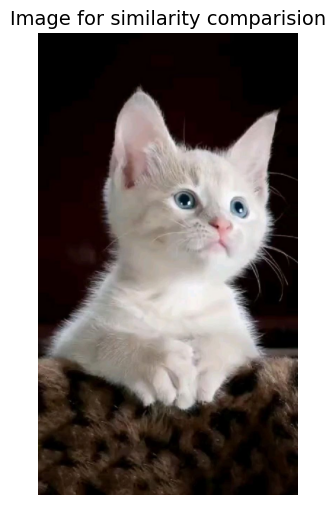

In [53]:
img1 = "/content/img 1.jpeg"

img1 = Image.open(img1)
plt.figure(figsize = (6,6))
plt.imshow(img1)
plt.axis("off")
plt.title("Image for similarity comparision",fontsize=14)
plt.show()

In [54]:


text_description = ["Two dogs in the show","A cat on a table",
                 "A picture of london at night ","A Dog sleeping on the couch",
                 "Two cats are fighting in  the garden"]

In [42]:
def display_image_and_compare(image_path,text_description):
  #loading image
  img = Image.open(image_path)

  #encode text and image (converting both into numbers)
  text_emb = model.encode(text_description)
  img_emb = model.encode(img)

  #compute similarity score
  similarity_score = np.dot(text_emb,img_emb.T)

  #find the best match
  best_match_index = np.argmax(similarity_score)
  best_match_desc = text_description[best_match_index]

  #print the final output
  print(f"\nBest match for the image is L {best_match_desc}with score of {similarity_score.max()}")
  plt.figure(figsize = (6,6))
  plt.imshow(img)
  plt.axis('off')
  plt.title("image for similarity comparision",fontsize =14)
  plt.show()



Best match for the image is L A cat on a tablewith score of 28.897214889526367


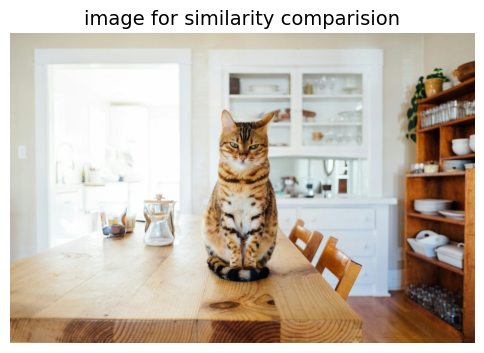

In [50]:
display_image_and_compare("/content/img 2.jpeg",text_description)


Best match for the image is L A Dog sleeping on the couchwith score of 27.08052635192871


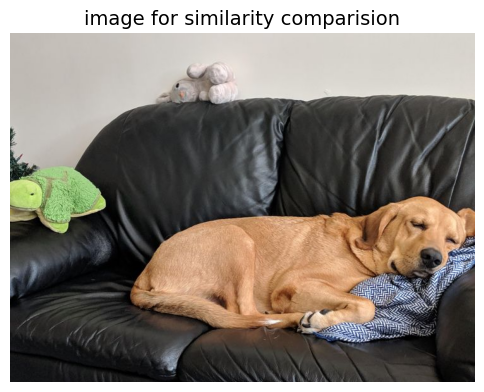

In [51]:
display_image_and_compare("/content/img 3.jpeg",text_description)


Best match for the image is L Two dogs in the showwith score of 16.633146286010742


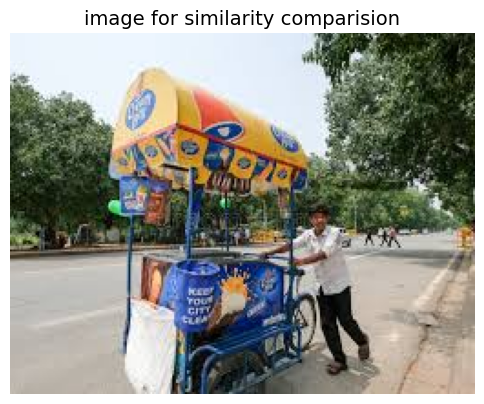

In [52]:
display_image_and_compare("/content/img 4.jpeg",text_description)